<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import copy

import seaborn
seaborn.set(palette='summer')

In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [4]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [6]:
dataset['train'].shape, dataset['test'].shape

((25000, 2), (25000, 2))

In [7]:
dataset['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [8]:
dataset['test'][0]

{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as 

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [5]:
sentences = []
word_threshold = 32

for text in tqdm(dataset['train']['text']):
    tokenized_text = sent_tokenize(text=text, language='english')
    for sentence in tokenized_text:
        words = word_tokenize(sentence, language='russian')
        if len(words) < word_threshold:
            sentences.append(sentence.lower())

  0%|          | 0/25000 [00:00<?, ?it/s]

In [ ]:
print("Всего предложений:", len(sentences))

Всего предложений: 200851


In [ ]:
sentences[:10]

['i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967.',
 'i also heard that at first it was seized by u.s.',
 "really, the sex and nudity scenes are few and far between, even then it's not shot like some cheaply made porno.",
 'while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema.',
 'i am curious-yellow is a good film for anyone wanting to study the meat and potatoes (no pun intended) of swedish cinema.',
 "but really, this film doesn't have much of a plot.",
 '"i am curious: yellow" is a risible and pretentious steaming pile.',
 "it doesn't matter what one's political views are because this film can hardly be taken seriously on any level.",
 "as for the claim that frontal male nudity is an automatic nc-17, that isn't true.",
 "i've seen r-rated films with male nudity."]

Посчитаем для каждого слова его встречаемость.

In [6]:
words = Counter()

for sentence in tqdm(sentences):
    for word in word_tokenize(text=sentence, language='english'):
        words[word] += 1

  0%|          | 0/198734 [00:00<?, ?it/s]

In [11]:
list(words.items())[:10]

[('i', 48972),
 ('rented', 226),
 ('am', 1507),
 ('curious-yellow', 2),
 ('from', 8795),
 ('my', 6942),
 ('video', 808),
 ('store', 256),
 ('because', 3896),
 ('of', 62759)]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [7]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

words_sorted = sorted(words.items(), key=lambda x: x[1], reverse=True)
for i in range(vocab_size):
    if i < 10:
        print(words_sorted[i][0])
    vocab.add(words_sorted[i][0])

.
the
,
a
and
of
to
is
it
i


In [8]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [14]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [9]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [10]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_data = word_tokenize(self.data[idx], language='russian')
        tokenized_sentence += [word2ind.get(char, self.unk_id) for char in tokenized_data]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [11]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [12]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [13]:
def evaluate(model, criterion, dataloader=eval_dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [14]:
def train_model(num_epochs, model, criterion, optimizer, dataloader=train_dataloader):
    losses = []
    perplexities = []

    for epoch in range(num_epochs):
        epoch_losses = []
        model.train()

        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()

            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion))

    return losses, perplexities

Напишем модифицированный train loop, который:  
1) Поддерживает Early stopping;  
2) Сохраняет лучшие веса модели на случай переобучения;  
3) Динамически изменяет lr если метрика перестала уменьшаться;  
4) Ускоряет обучение с помощью использования float меньшей размерности (и не дает градиентам обнулиться);  
5) Обрезает градиенты, не допуская взрыва градиентов

In [15]:
def train_model_AMP(num_epochs, model, criterion, optimizer, dataloader=train_dataloader):
    losses = []
    perplexities = []

    best_perplexity = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    epochs_count = 0

    scaler = GradScaler('cuda')

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                           factor=0.5, patience=1,
                                                           min_lr=1e-6)


    for epoch in range(num_epochs):
        epoch_losses = []
        model.train()

        for batch in tqdm(dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
                loss = criterion(logits, batch['target_ids'].flatten())

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(loss.item())

        val_perplexity = evaluate(model, criterion)
        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(epoch_loss)
        perplexities.append(val_perplexity)

        scheduler.step(val_perplexity)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch: {epoch}, loss: {epoch_loss:.4f}, perplexity: {val_perplexity:.2f}, learning rate: {current_lr}")

        if val_perplexity < best_perplexity:
            best_perplexity = val_perplexity
            best_weights = copy.deepcopy(model.state_dict())
            epochs_count = 0
        else:
            epochs_count += 1
            if epochs_count >= 3:
                print("Early stopping")
                break

    model.load_state_dict(best_weights)
    return losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

Возьмем очень простую модель GRU, с небольшим размером эмбеддингов (64) и скрытого слоя линейной части (128). Также добавим регяуляризацию (dropout, LayerNorm).

In [16]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, emb_dim, batch_first=True)
        self.linear = nn.Linear(emb_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.layernorm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.non_lin = nn.Tanh()

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.gru(embeddings)
        output = self.layernorm(output)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [17]:
model_params_first = {'vocab_size': len(vocab),
                      'emb_dim': 64,
                      'hidden_dim': 128,
                      'dropout': 0.1}

В качестве оптимизатора используем алгоритм Adam с регуляризацией весов.

In [18]:
model = LanguageModel(**model_params_first).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.001)

In [19]:
losses, perplexities = train_model_AMP(num_epochs=10, model=model,
                                   criterion=criterion, optimizer=optimizer)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 0, loss: 5.6592, perplexity: 180.94, learning rate: 0.001


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 1, loss: 5.0675, perplexity: 150.98, learning rate: 0.001


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Epoch: 7, loss: 4.5490, perplexity: 124.94, learning rate: 0.001


Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 8, loss: 4.5119, perplexity: 124.61, learning rate: 0.001


Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 9, loss: 4.4788, perplexity: 124.70, learning rate: 0.001


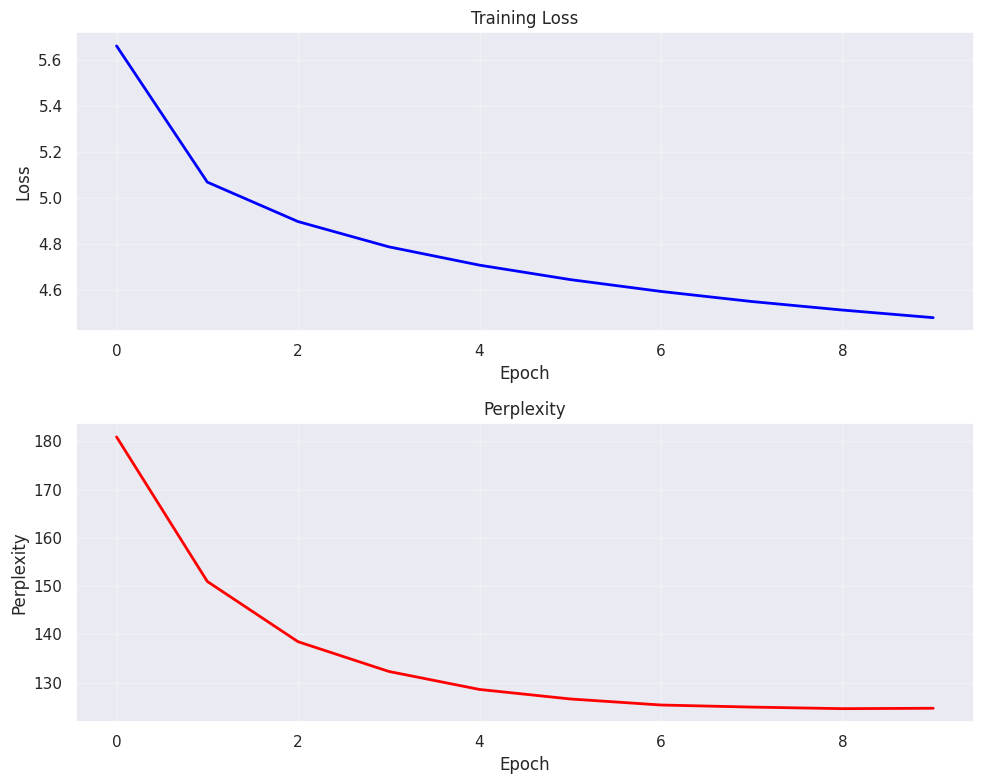

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(np.arange(len(losses)), losses, 'b-', linewidth=2)
ax1.set_title('Training Loss', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(len(perplexities)), perplexities, 'r-', linewidth=2)
ax2.set_title('Perplexity', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
print(f'Значение perplexity на тестовой выборке: {evaluate(model, criterion, dataloader=test_dataloader):.2f}')

Значение perplexity на тестовой выборке: 124.55


Получаем значение **perplexity = 124.55**. Отдельно это число мало о чем говорит, попробуем его нормализовать и проинтерпретировать.  
  
Минимум perplexity равен 1, достигается в случае, если все вероятности равны 1.   
Тогда **perplexity = exp( - sum(log(1) / k)) = exp(0) = 1**.  
В случае равномерных предсказаний, **perplexity = exp(sum(log(1 / k) / k)) = exp( - k * log(1 / k) / k) = exp( - log(1 / k)) = k**.  
  
То есть, в нашем случае значения перплексии могут быть в диапазоне от 1 до 40004. Значит, значение 124.55 совсем неплохое, можно сказать, что наша модель лучше случайной в ~ 318 раз.

### Генерация текста

In [27]:
def generate_sequence(model, starting_seq, max_seq_len=128):
    device = 'cpu'
    model = model.to(device)
    model.eval()

    start_words = starting_seq.strip().split()

    input_indices = [word2ind['<bos>']]
    for w in start_words:
        input_indices.append(word2ind.get(w, word2ind['<unk>']))

    input_ids = torch.LongTensor(input_indices).to(device)

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids)
            next_word_logits = logits[-1]

            next_word_idx = next_word_logits.argmax().item()
            input_ids = torch.cat([input_ids, torch.tensor([next_word_idx], device=device)])

            if next_word_idx == word2ind['<eos>']:
                break

    generated_indices = input_ids.tolist()
    generated_words = [ind2word[idx] for idx in generated_indices if idx != word2ind['<bos>']]
    return ' '.join(generated_words)

In [28]:
def generate_sequence_topk(model, starting_seq, max_seq_len=128, top_k=10):
    device = 'cpu'
    model = model.to(device)
    model.eval()

    start_words = starting_seq.strip().split()
    input_indices = [word2ind['<bos>']]

    for w in start_words:
        input_indices.append(word2ind.get(w, word2ind['<unk>']))

    input_ids = torch.LongTensor(input_indices).to(device)

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids)
            next_word_logits = logits[-1]

            if top_k > 0:
                top_k_vals, top_k_indices = torch.topk(next_word_logits, top_k)
                mask = torch.full_like(next_word_logits, -float('Inf'))
                mask[top_k_indices] = top_k_vals
                next_word_logits = mask

            probs = torch.softmax(next_word_logits, dim=-1)
            next_word_idx = torch.multinomial(probs, num_samples=1).item()

            input_ids = torch.cat([input_ids, torch.tensor([next_word_idx], device=device)])

            if next_word_idx == word2ind['<eos>']:
                break

    generated_indices = input_ids.tolist()
    generated_words = [ind2word[idx] for idx in generated_indices if idx != word2ind['<bos>']]
    return ' '.join(generated_words)

In [29]:
def generate_sequence_topp(model, starting_seq, max_seq_len=128, top_p=0.9) :
    device = 'cpu'
    model = model.to(device)
    model.eval()

    start_words = starting_seq.strip().split()
    input_indices = [word2ind['<bos>']]

    for w in start_words:
        input_indices.append(word2ind.get(w, word2ind['<unk>']))

    input_ids = torch.LongTensor(input_indices).to(device)

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids)
            next_word_logits = logits[-1]

            if top_p > 0.0:
                sorted_logits, sorted_indices = torch.sort(next_word_logits, descending=True)
                cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)

                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
                sorted_indices_to_remove[0] = False

                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                next_word_logits[indices_to_remove] = -float('Inf')

            probs = torch.softmax(next_word_logits, dim=-1)
            next_word_idx = torch.multinomial(probs, num_samples=1).item()

            input_ids = torch.cat([input_ids, torch.tensor([next_word_idx], device=device)])

            if next_word_idx == word2ind['<eos>']:
                break

    generated_indices = input_ids.tolist()
    generated_words = [ind2word[idx] for idx in generated_indices if idx != word2ind['<bos>']]
    return ' '.join(generated_words)

In [30]:
print(generate_sequence(model=model, starting_seq='this movie is '))
print(generate_sequence_topk(model=model, starting_seq='this movie is '))
print(generate_sequence_topp(model=model, starting_seq='this movie is '))

this movie is a great movie . <eos>
this movie is so bad as a <unk> of the movie , it just had me . <eos>
this movie is quite entertaining and worst like the original , that i read it . <eos>


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Радикально усложним модель: будем использовать архитектуру LSTM с двумя RNN блоками (num_layers), кратно увеличим размеры эмбеддингов (512), вектора скрытого состояния (768) и линейного слоя (1024). Добавим dropout и в слой LSTM.

In [31]:
class LanguageModel_LSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_size, num_layers,
                 dropout_rnn, hidden_dim, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=num_layers,
                            dropout=dropout_rnn, batch_first=True)
        self.linear = nn.Linear(hidden_size, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(p=dropout)

        self.tanh= nn.Tanh()

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:

        embeddings = self.dropout(self.embedding(input_batch))
        output, _ = self.lstm(embeddings)
        output = self.layer_norm(output)
        output = self.dropout(self.linear(self.tanh(output)))
        projection = self.projection(output)

        return projection

In [32]:
model_params_LSTM = {'vocab_size': len(vocab),
                      'emb_dim': 512,
                      'hidden_size': 768,
                      'num_layers': 2,
                      'dropout_rnn': 0.3,
                      'hidden_dim': 1024,
                      'dropout': 0.3}

Изменим lr и weight_decay, увеличим число эпох до 15.

In [33]:
model = LanguageModel_LSTM(**model_params_LSTM).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.001)

In [34]:
losses, perplexities = train_model_AMP(num_epochs=15, model=model,
                                   criterion=criterion, optimizer=optimizer)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 0, loss: 5.2322, perplexity: 123.04, learning rate: 0.0003


Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 1, loss: 4.7479, perplexity: 103.73, learning rate: 0.0003


Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Epoch: 6, loss: 4.0965, perplexity: 88.94, learning rate: 0.0003


Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 7, loss: 4.0174, perplexity: 89.70, learning rate: 0.00015


Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Epoch: 8, loss: 3.8870, perplexity: 89.59, learning rate: 0.00015
Early stopping


Модель начала переобучаться, и обучение завершилось досрочно после 8 эпох.

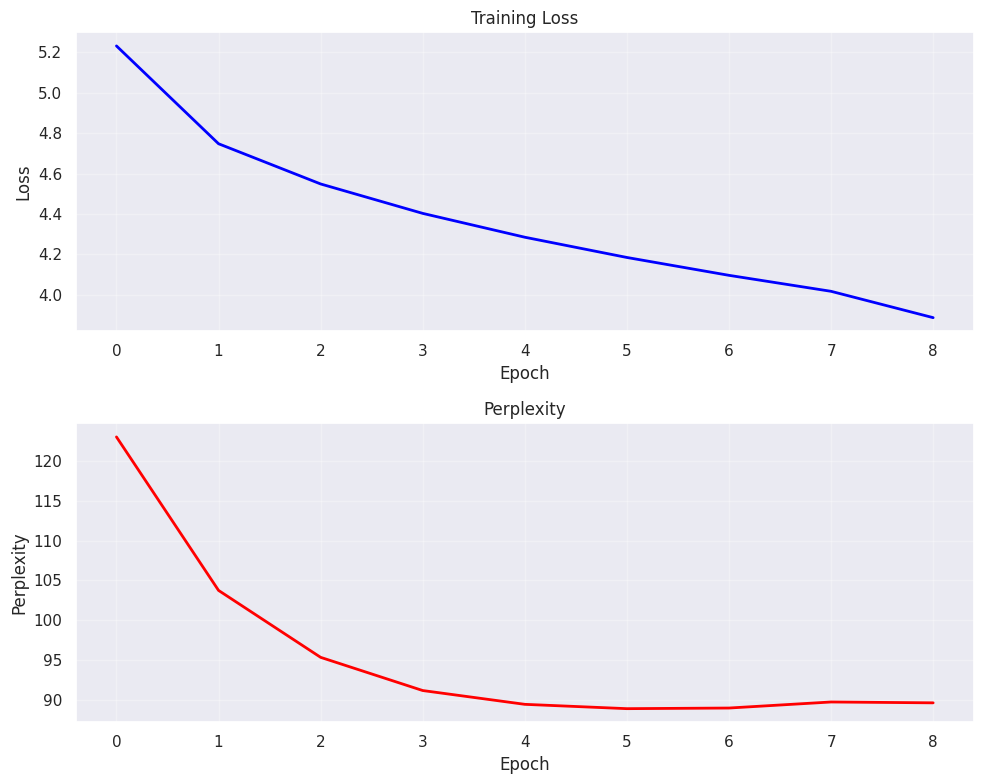

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(np.arange(len(losses)), losses, 'b-', linewidth=2)
ax1.set_title('Training Loss', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(len(perplexities)), perplexities, 'r-', linewidth=2)
ax2.set_title('Perplexity', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
print(f'Значение perplexity на тестовой выборке: {evaluate(model, criterion, dataloader=test_dataloader):.2f}')

Значение perplexity на тестовой выборке: 88.80


Значение **perplexity = 88.80**, почти на треть меньше чем у предыдущей модели. Лучше случайной в ~ 444 раза.

### Генерация текста

In [37]:
print(generate_sequence(model=model, starting_seq='this movie is '))
print(generate_sequence_topk(model=model, starting_seq='this movie is '))
print(generate_sequence_topp(model=model, starting_seq='this movie is '))

this movie is a great film . <eos>
this movie is not funny ! ! ! ! ! ! ! ! ! ! ! ! <eos>
this movie is just what it is done . <eos>


### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

In [39]:
import pandas as pd
results = pd.DataFrame({"Модель": range(2),
                        "Минимальная перплексия": [124.55, 88.80]}).set_index("Модель")
results

,Минимальная перплексия
Модель,
0,124.55
1,88.80


Первая простая модель (GRU с малым количеством обучаемых параметров и слабой регуляризацией) показала значение перплексии 124.55.  
Вторая модель - LSTM с двумя RNN блоками, увеличенными размерами эмбеддингов и большим количеством параметров на линейном слое достигла perplexity = 90.41, что на 28% меньше, чем у первой. Также, несмотря на более сильную регуляризацию, данная модель переобучилась.

Можно предположить, что дальнейшее улучшение качества может быть достигнуто усложнением модели и усилением регуляризации для борьбы с переобучением.
В пользу этого предположения говорит и форма графиков ошибок и значений перплексии: они убывают медленно и очень быстро выходят на плато, будто модель почти сразу упирается в свой потолок (локальный минимум). Выйти из него получится с помощью более сложной модели.